In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations

%matplotlib widget

In [2]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
spme = pybamm.lithium_ion.SPMe()

In [3]:
hppc_data_raw = pd.read_csv('./data/hppc/' + 'GMJuly2022_CELL017_RPT_1_P25C_25P0PSI_20221121_R0_CH040_20221121171209_37_1_8_2818580181_HPPC' + '.csv')
hppc_data = hppc_data_raw
hppc_data_raw.head()

,Unnamed: 0,Time [s],Current [A],Voltage [V],Ah throughput [A.h]
0,3577538,2022-11-21 21:22:10-05:00,-0.2996,4.1693,809.512275
1,3577539,2022-11-21 21:22:11-05:00,-0.2998,4.1688,809.512375
2,3577540,2022-11-21 21:22:12-05:00,-0.3000,4.1686,809.512375
3,3577541,2022-11-21 21:22:13-05:00,-0.2998,4.1683,809.512475
4,3577542,2022-11-21 21:22:14-05:00,-0.2997,4.1680,809.512575


In [4]:
# hppc_data['Time [s]'] = hppc_data_raw['Time [s]'].str.replace(r'-05:00', '', regex=True)
hppc_data['Time [s]'] = pd.to_datetime(hppc_data['Time [s]'] , format='%Y-%m-%d %H:%M:%S-%f:00')
data_time = hppc_data['Time [s]']-hppc_data['Time [s]'][0]
data_time = data_time.values/1e9
data_time = data_time.astype('float')
data_current = hppc_data_raw['Current [A]']
data_current = data_current.values
t_sim = np.arange(0,data_time[-1],0.1)
data_current = np.interp(t_sim, data_time, data_current, left=None, right=None, period=None)
data_voltage= hppc_data['Voltage [V]']
data_voltage = data_voltage.values
data_voltage = np.interp(t_sim, data_time, data_voltage, left=None, right=None, period=None)

In [5]:
timescale = parameter_values.evaluate(spme.timescale)
# discharge is positive current in PyBaMM
current_interpolant = pybamm.Interpolant(
  #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
  t_sim, -data_current, timescale * pybamm.t
)
parameter_values["Current function [A]"] = current_interpolant

In [6]:
sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve(t_eval=t_sim,initial_soc =1)

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

CasADi - 2023-09-20 13:22:37 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


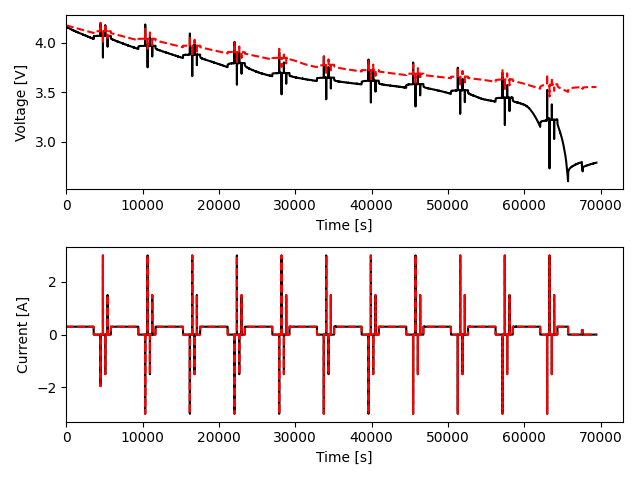

In [9]:
fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t_sim,data_voltage,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,-data_current,'k')
ax2.plot(t,I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()